# Model Evaluation v3



## Objective

This notebook evaluates the v3 XGBoost models and compares them against previous iterations of the pipeline.

The goals are to:

- assess v3 prediction accuracy for both target coordinates,
- compare v1, v2 and v3 performance,
- analyze error distributions and failure cases,
- Inspect performance across player group,
- identufy whethere v3 improvements justify the added feature complexity.

---

## Evaluation Strategy

To ensure fair comparison, this notebook follows the same evaluation framework used in earlier iterations:

    -reconstruct the validation dataset.
    -align predictions using perserved indices.
    -compute standard regression metrics.
    -analyze error distributions.
    -inspect hard examples.
    
This allows performance changes to be attributed to feature engineering and model choice rather than evaluation differences.


In [2]:
import sys 
from pathlib import Path 
import json 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sys.path.append(str(Path("..").resolve()))

from src.config import MODELS_DIR, PROCESSED_DIR

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## Load Evaluation Artifacts

We load the saved validation predictions and metadata from the v3 training run, along with the processed v3 dataset used to reconstruct the validation subset.

In [3]:
run_dir= MODELS_DIR / "baseline_v3_xgboost"

predictions_path= run_dir/ "validation_predictions.parquet"
metadata_path= run_dir/"training_metadata.json"
dataset_path= PROCESSED_DIR/ "baseline_train_v3.parquet"

pred_df= pd.read_parquet(predictions_path)
full_df=pd.read_parquet(dataset_path)

with open(metadata_path, "r") as f:
    metadata= json.load(f)
    
print("Validations prediction shape: ", pred_df.shape)
display(pred_df.head())

print("\nTraining metadata: ")
display(metadata)

Validations prediction shape:  (30825, 6)


,ball_land_x_true,ball_land_x_pred,ball_land_y_true,ball_land_y_pred,error_x,error_y
6371,55.57,55.454952,27.799999,28.032030,-0.115047,0.232031
6372,55.57,55.815922,27.799999,27.975599,0.245922,0.175600
6373,55.57,55.921875,27.799999,28.152121,0.351875,0.352121
6374,55.57,55.751289,27.799999,28.279974,0.181290,0.479975
6375,55.57,55.884941,27.799999,28.277689,0.314941,0.477690



Training metadata: 


{'run_name': 'baseline_v3_xgboost',
 'created_at': '2026-04-14T20:39:07.473015',
 'input_dataset': 'C:\\Users\\jmontanez\\Documents\\nfl-big-data-bowl-2026\\data\\processed\\baseline_train_v3.parquet',
 'n_rows_total': 152305,
 'n_rows_train': 121480,
 'n_rows_valid': 30825,
 'target_columns': ['ball_land_x', 'ball_land_y'],
 'feature_columns_raw': ['x',
  'y',
  's',
  'a',
  'dir',
  'o',
  'absolute_yardline_number',
  'player_weight',
  'player_height_inches',
  'player_age',
  'is_moving_right',
  'player_position',
  'player_side',
  'player_role',
  'dx_to_ball',
  'dy_to_ball',
  'dist_to_ball',
  'speed_x',
  'speed_y',
  'momentum',
  'momentum_x',
  'momentum_y',
  'x_centered',
  'y_centered',
  'dist_from_field_center',
  'speed_bin_code',
  'acc_x',
  'acc_y',
  'dir_minus_o',
  'x_prev',
  'y_prev',
  's_prev',
  'a_prev',
  'delta_x',
  'delta_y',
  'delta_s',
  'delta_a'],
 'feature_columns_trained': ['x',
  'y',
  's',
  'a',
  'dir',
  'o',
  'absolute_yardline_numbe

## Rebuild Validation Slice 

We reconstruct the validation ubset using the same grouped split logic by 'game_id' that was used during training.

In [4]:
unique_games = full_df["game_id"].dropna().unique()
unique_games=np.sort(unique_games)

rng= np.random.default_rng(42)
shuffled_games=rng.permutation(unique_games)

split_idx= int(0.8*len(shuffled_games))
train_games= set(shuffled_games[:split_idx])
valid_games=set(shuffled_games[split_idx:])

valid_df=full_df[full_df["game_id"].isin(valid_games)].copy()

print("Validation slice shape:",  valid_df.shape)
display(valid_df.head())

Validation slice shape: (30825, 48)


,game_id,play_id,nfl_id,player_name,frame_id,x,y,s,a,dir,o,absolute_yardline_number,player_weight,player_height_inches,player_age,is_moving_right,player_position,player_side,player_role,ball_land_x,ball_land_y,num_frames_output,dist_to_ball,speed_x,speed_y,acc_vector,x_centered,y_centered,momentum,speed_times_dir,x_times_speed,speed_bin_code,dx_to_ball,dy_to_ball,acc_x,acc_y,dir_minus_o,momentum_x,momentum_y,dist_from_field_center,x_prev,y_prev,s_prev,a_prev,delta_x,delta_y,delta_s,delta_a
6371,2023091000,185,46123,Jessie Bates,1,55.20,30.85,1.18,0.87,225.81,102.75,66,200,73,26,0,SS,Defense,Defensive Coverage,55.57,27.799999,9,3.072361,-0.822507,-0.846098,0.87,-4.80,4.20,236.0,266.4558,65.1360,1,0.37,-3.050001,-0.606425,-0.623818,123.06,-164.501432,-169.219617,6.378087,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
6372,2023091000,185,46123,Jessie Bates,2,55.11,30.76,1.43,1.45,224.33,104.45,66,200,73,26,0,SS,Defense,Defensive Coverage,55.57,27.799999,9,2.995531,-1.022918,-0.999270,1.45,-4.89,4.11,286.0,320.7919,78.8073,1,0.46,-2.960001,-1.037224,-1.013245,119.88,-204.583507,-199.853919,6.387817,55.20,30.85,1.18,0.87,-0.09,24.26,53.93,54.24
6373,2023091000,185,46123,Jessie Bates,3,55.00,30.65,1.63,1.64,223.52,105.77,66,200,73,26,0,SS,Defense,Defensive Coverage,55.57,27.799999,9,2.906442,-1.181968,-1.122431,1.64,-5.00,4.00,326.0,364.3376,89.6500,1,0.57,-2.850001,-1.189220,-1.129317,117.75,-236.393699,-224.486122,6.403124,55.11,30.76,1.43,1.45,-0.11,24.24,53.57,53.55
6374,2023091000,185,46123,Jessie Bates,4,54.88,30.52,1.87,1.81,222.09,107.67,66,200,73,26,0,SS,Defense,Defensive Coverage,55.57,27.799999,9,2.806155,-1.387714,-1.253456,1.81,-5.12,3.87,374.0,415.3083,102.6256,1,0.69,-2.720001,-1.343188,-1.213238,114.42,-277.542723,-250.691119,6.418045,55.00,30.65,1.63,1.64,-0.12,24.23,53.25,53.24
6375,2023091000,185,46123,Jessie Bates,5,54.75,30.37,2.14,1.85,220.78,108.36,66,200,73,26,0,SS,Defense,Defensive Coverage,55.57,27.799999,9,2.697648,-1.620457,-1.397755,1.85,-5.25,3.72,428.0,472.4692,117.1650,2,0.82,-2.570001,-1.400863,-1.208339,112.42,-324.091485,-279.550906,6.434353,54.88,30.52,1.87,1.81,-0.13,24.23,52.88,52.94


## Align Validation Data with Predictions

The validation predictions saved during training preserved the original validation index.

We align the validation dataset with predictions using this shared index to ensure row-level consistency before computing evaluation metrics and error analysis.

In [5]:
# Align validation rows with saved prediction rows using the preserved index
valid_df = valid_df.loc[pred_df.index].copy()

# Sanity checks
assert len(valid_df) == len(pred_df), "Mismatch between validation data and prediction rows."
assert valid_df.index.equals(pred_df.index), "Validation and prediction indices are not aligned."

# Build evaluation dataframe
eval_df = valid_df.copy()

eval_df["ball_land_x_pred"] = pred_df["ball_land_x_pred"]
eval_df["ball_land_y_pred"] = pred_df["ball_land_y_pred"]

eval_df["error_x"] = eval_df["ball_land_x_pred"] - eval_df["ball_land_x"]
eval_df["error_y"] = eval_df["ball_land_y_pred"] - eval_df["ball_land_y"]

eval_df["abs_error_x"] = eval_df["error_x"].abs()
eval_df["abs_error_y"] = eval_df["error_y"].abs()

print("Evaluation dataframe shape:", eval_df.shape)
display(eval_df.head())

Evaluation dataframe shape: (30825, 54)


,game_id,play_id,nfl_id,player_name,frame_id,x,y,s,a,dir,o,absolute_yardline_number,player_weight,player_height_inches,player_age,is_moving_right,player_position,player_side,player_role,ball_land_x,ball_land_y,num_frames_output,dist_to_ball,speed_x,speed_y,acc_vector,x_centered,y_centered,momentum,speed_times_dir,x_times_speed,speed_bin_code,dx_to_ball,dy_to_ball,acc_x,acc_y,dir_minus_o,momentum_x,momentum_y,dist_from_field_center,x_prev,y_prev,s_prev,a_prev,delta_x,delta_y,delta_s,delta_a,ball_land_x_pred,ball_land_y_pred,error_x,error_y,abs_error_x,abs_error_y
6371,2023091000,185,46123,Jessie Bates,1,55.20,30.85,1.18,0.87,225.81,102.75,66,200,73,26,0,SS,Defense,Defensive Coverage,55.57,27.799999,9,3.072361,-0.822507,-0.846098,0.87,-4.80,4.20,236.0,266.4558,65.1360,1,0.37,-3.050001,-0.606425,-0.623818,123.06,-164.501432,-169.219617,6.378087,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,55.454952,28.032030,-0.115047,0.232031,0.115047,0.232031
6372,2023091000,185,46123,Jessie Bates,2,55.11,30.76,1.43,1.45,224.33,104.45,66,200,73,26,0,SS,Defense,Defensive Coverage,55.57,27.799999,9,2.995531,-1.022918,-0.999270,1.45,-4.89,4.11,286.0,320.7919,78.8073,1,0.46,-2.960001,-1.037224,-1.013245,119.88,-204.583507,-199.853919,6.387817,55.20,30.85,1.18,0.87,-0.09,24.26,53.93,54.24,55.815922,27.975599,0.245922,0.175600,0.245922,0.175600
6373,2023091000,185,46123,Jessie Bates,3,55.00,30.65,1.63,1.64,223.52,105.77,66,200,73,26,0,SS,Defense,Defensive Coverage,55.57,27.799999,9,2.906442,-1.181968,-1.122431,1.64,-5.00,4.00,326.0,364.3376,89.6500,1,0.57,-2.850001,-1.189220,-1.129317,117.75,-236.393699,-224.486122,6.403124,55.11,30.76,1.43,1.45,-0.11,24.24,53.57,53.55,55.921875,28.152121,0.351875,0.352121,0.351875,0.352121
6374,2023091000,185,46123,Jessie Bates,4,54.88,30.52,1.87,1.81,222.09,107.67,66,200,73,26,0,SS,Defense,Defensive Coverage,55.57,27.799999,9,2.806155,-1.387714,-1.253456,1.81,-5.12,3.87,374.0,415.3083,102.6256,1,0.69,-2.720001,-1.343188,-1.213238,114.42,-277.542723,-250.691119,6.418045,55.00,30.65,1.63,1.64,-0.12,24.23,53.25,53.24,55.751289,28.279974,0.181290,0.479975,0.181290,0.479975
6375,2023091000,185,46123,Jessie Bates,5,54.75,30.37,2.14,1.85,220.78,108.36,66,200,73,26,0,SS,Defense,Defensive Coverage,55.57,27.799999,9,2.697648,-1.620457,-1.397755,1.85,-5.25,3.72,428.0,472.4692,117.1650,2,0.82,-2.570001,-1.400863,-1.208339,112.42,-324.091485,-279.550906,6.434353,54.88,30.52,1.87,1.81,-0.13,24.23,52.88,52.94,55.884941,28.277689,0.314941,0.477690,0.314941,0.477690


## Overall Performance Metrics

We compute standard regression metrics for both target variables:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

These provide a high-level view of model accuracy.

In [8]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

metrics_x = regression_metrics(eval_df["ball_land_x"], eval_df["ball_land_x_pred"])
metrics_y = regression_metrics(eval_df["ball_land_y"], eval_df["ball_land_y_pred"])

metrics_df = pd.DataFrame({
    "ball_land_x": metrics_x,
    "ball_land_y": metrics_y,
})

display(metrics_df)

,ball_land_x,ball_land_y
MAE,0.403258,0.269173
RMSE,0.610052,0.479312
R2,0.999424,0.999086


## Compare v1,v2 and v3

To understand the value of the v3 pipeline, we compare its metrics against the saved results from v1 and v2.

In [12]:
v1_metadata_path=MODELS_DIR/"baseline_v1"/"training_metadata.json"
v2_metadata_path=MODELS_DIR/"baseline_v2"/"training_metadata.json"

with open(v1_metadata_path,"r") as f:
    metadata_v1=json.load(f)

with open(v2_metadata_path,"r") as f:
    metadata_v2=json.load(f)
    
comparison_table = pd.DataFrame({
    "v1_ball_land_x":metadata_v1["metrics_ball_land_x"],
    "v2_ball_land_x":metadata_v2["metrics_ball_land_x"],
    "v3_ball_land_x":metrics_x,
    "v1_ball_land_y":metadata_v1["metrics_ball_land_y"],
    "v2_ball_land_y":metadata_v1["metrics_ball_land_y"],
    "v3_ball_land_y":metrics_y,
})

display(comparison_table)

,v1_ball_land_x,v2_ball_land_x,v3_ball_land_x,v1_ball_land_y,v2_ball_land_y,v3_ball_land_y
MAE,6.835385,4.195151,0.403258,7.563908,7.563908,0.269173
RMSE,9.061241,5.596259,0.610052,9.618264,9.618264,0.479312
R2,0.872998,0.951557,0.999424,0.631956,0.631956,0.999086


## Error Summary 

We inspect average and median absolute error to better understand the typical prediction error magnitude in v3.

In [13]:
error_summary= pd.DataFrame({
    "mean_abs_error_x":[eval_df["abs_error_x"].mean()],
    "median_abs_error_x":[eval_df["abs_error_x"].median()],
    "mean_abs_error_y":[eval_df["abs_error_y"].mean()],
    "median_abs_error_y":[eval_df["abs_error_y"].median()],
})

display(error_summary)

,mean_abs_error_x,median_abs_error_x,mean_abs_error_y,median_abs_error_y
0,0.403258,0.272194,0.269173,0.175282


## Error Distribution Analysis

We inspect the distribution of signed and absolute errors to understand model bias, variance and outlier behavior.

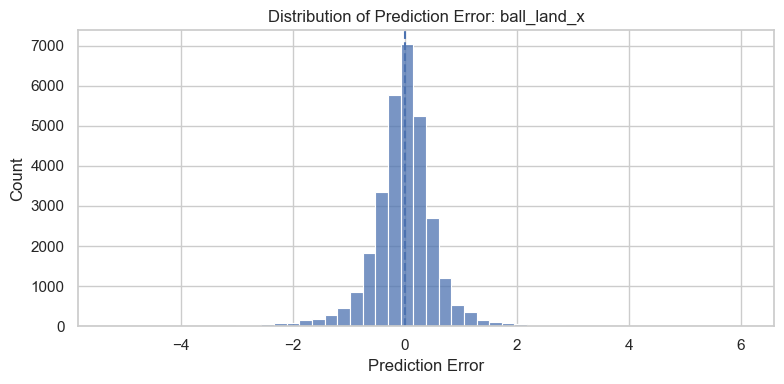

In [14]:
plt.figure(figsize=(8,4))
sns.histplot(eval_df["error_x"], bins=50)
plt.axvline(0, linestyle="--")
plt.title("Distribution of Prediction Error: ball_land_x")
plt.xlabel("Prediction Error")
plt.tight_layout()
plt.show()

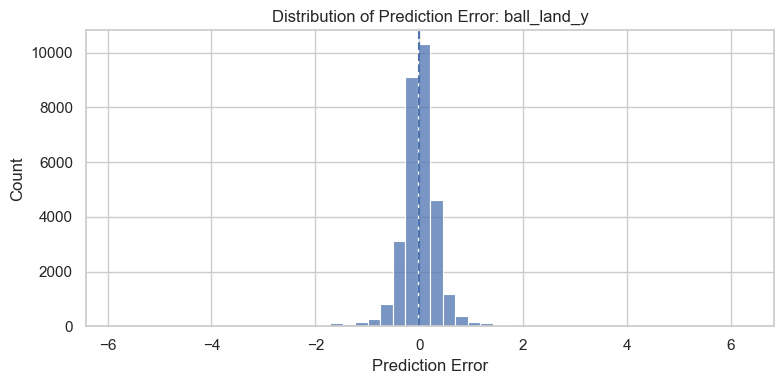

In [15]:
plt.figure(figsize=(8,4))
sns.histplot(eval_df["error_y"], bins=50)
plt.axvline(0, linestyle="--")
plt.title("Distribution of Prediction Error: ball_land_y")
plt.xlabel("Prediction Error")
plt.tight_layout()
plt.show()

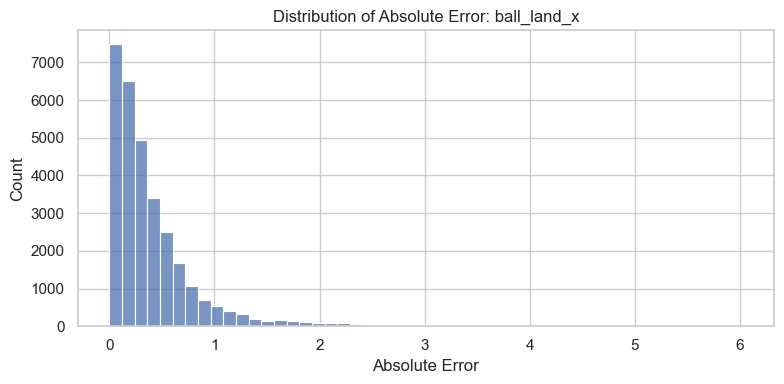

In [16]:
plt.figure(figsize=(8,4))
sns.histplot(eval_df["abs_error_x"], bins=50)
plt.title("Distribution of Absolute Error: ball_land_x")
plt.xlabel("Absolute Error")
plt.tight_layout()
plt.show()

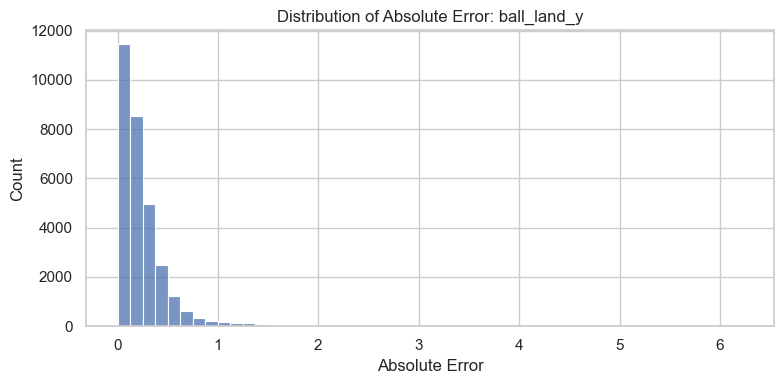

In [17]:
plt.figure(figsize=(8,4))
sns.histplot(eval_df["abs_error_y"], bins=50)
plt.title("Distribution of Absolute Error: ball_land_y")
plt.xlabel("Absolute Error")
plt.tight_layout()
plt.show()

## Prediction vs Ground Truth

We compare predicted values against the true landing coordinates to asses calibration and dispersion.

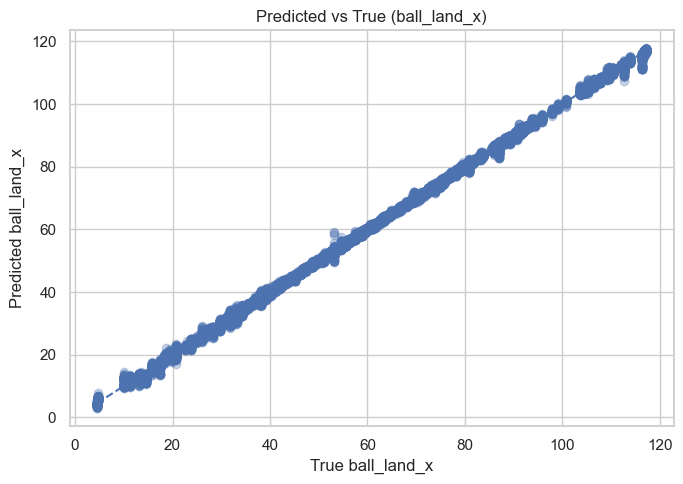

In [18]:
plt.figure(figsize=(7,5))
plt.scatter(eval_df["ball_land_x"], eval_df["ball_land_x_pred"], alpha=0.3)
plt.plot([eval_df["ball_land_x"].min(), eval_df["ball_land_x"].max()],
         [eval_df["ball_land_x"].min(), eval_df["ball_land_x"].max()], 
         linestyle="--"
)
plt.title("Predicted vs True (ball_land_x)")
plt.xlabel("True ball_land_x")
plt.ylabel("Predicted ball_land_x")
plt.tight_layout()
plt.show()

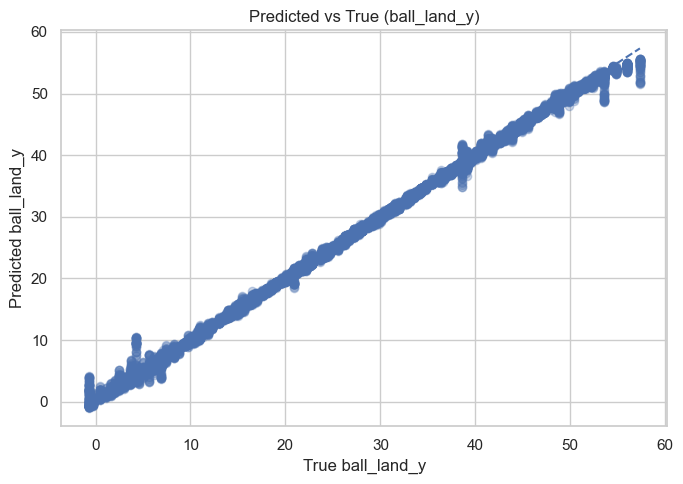

In [19]:
plt.figure(figsize=(7,5))
plt.scatter(eval_df["ball_land_y"], eval_df["ball_land_y_pred"], alpha=0.3)
plt.plot([eval_df["ball_land_y"].min(), eval_df["ball_land_y"].max()],
         [eval_df["ball_land_y"].min(), eval_df["ball_land_y"].max()], 
         linestyle="--"
)
plt.title("Predicted vs True (ball_land_y)")
plt.xlabel("True ball_land_y")
plt.ylabel("Predicted ball_land_y")
plt.tight_layout()
plt.show()

## Segment-Level Analysis

We evaluate prediction error by player role and player position to identify which groups benefied most from the v3 improvements.

In [21]:
role_error= (
    eval_df.groupby("player_role")[["abs_error_x", "abs_error_y"]]
    .mean()
    .sort_values("abs_error_x", ascending=False)
)

display(role_error)

,abs_error_x,abs_error_y
player_role,,
Targeted Receiver,0.420766,0.277226
Defensive Coverage,0.395747,0.265719


In [22]:
position_error= (
    eval_df.groupby("player_position")[["abs_error_x", "abs_error_y"]]
    .mean()
    .sort_values("abs_error_x", ascending=False)
)

display(position_error)

,abs_error_x,abs_error_y
player_position,,
WR,0.463611,0.295232
CB,0.433829,0.255693
FS,0.395032,0.264931
OLB,0.392798,0.303482
DE,0.390236,0.239884
TE,0.381547,0.245312
MLB,0.378638,0.243093
SS,0.374144,0.315024
S,0.316676,0.186346


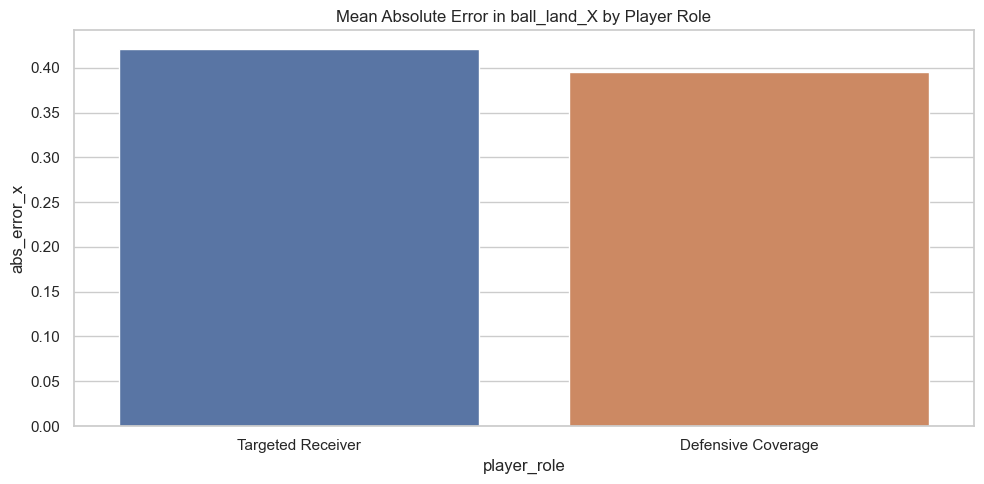

In [23]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=role_error.reset_index(),
    x="player_role",
    y="abs_error_x"
)
plt.title("Mean Absolute Error in ball_land_X by Player Role")
plt.tight_layout()
plt.show()

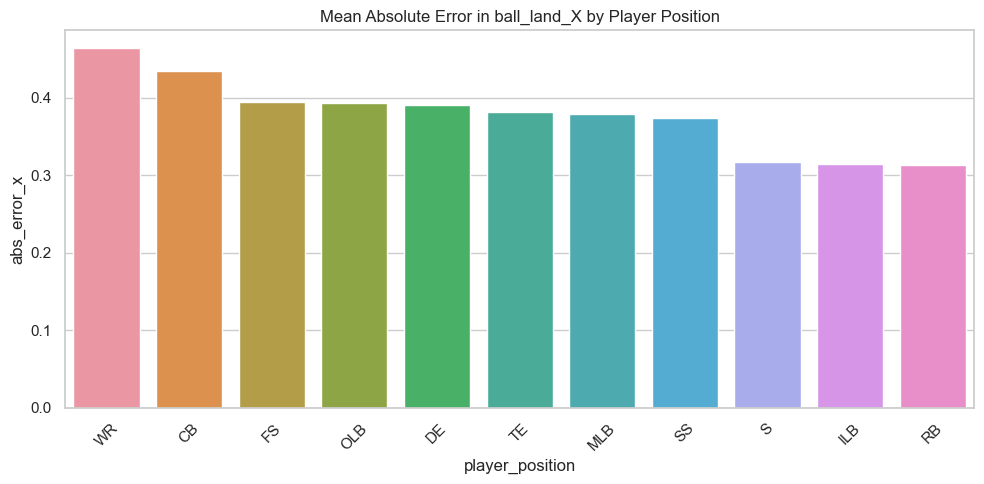

In [24]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=position_error.reset_index().head(15),
    x="player_position",
    y="abs_error_x"
)
plt.title("Mean Absolute Error in ball_land_X by Player Position")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Error by Temporal Horizon

We analyze error by **"num_frames_output"** to asses whether longer output horizons remain more difficult for the model.

In [25]:
horizon_eval=(
    eval_df.groupby("num_frames_output")[["abs_error_x","abs_error_y"]]
    .mean()
    .reset_index()
    .sort_values("num_frames_output")
)

display(horizon_eval.head(20))

,num_frames_output,abs_error_x,abs_error_y
0,5,0.272869,0.196184
1,6,0.560027,0.219398
2,7,0.329149,0.207195
3,8,0.306623,0.181726
4,9,0.303443,0.207708
5,10,0.297033,0.211448
6,11,0.275052,0.197097
7,12,0.353955,0.267165
8,13,0.396730,0.372759
9,14,0.502183,0.328079


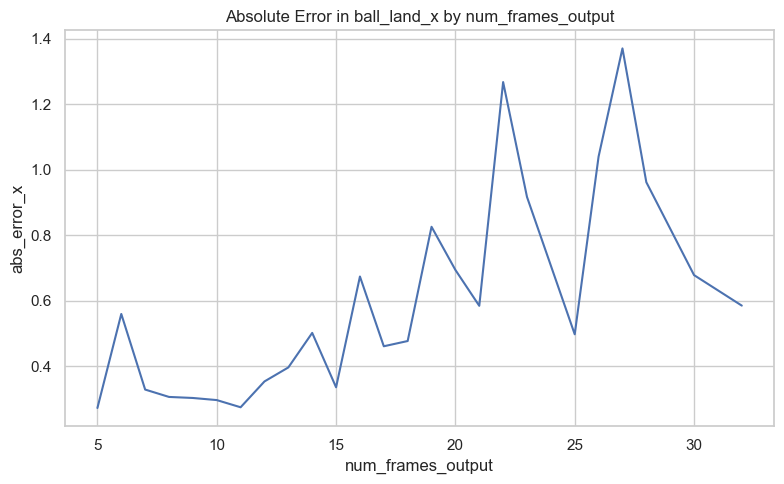

In [26]:
plt.figure(figsize=(8,5))
sns.lineplot(data=horizon_eval, x="num_frames_output", y="abs_error_x")
plt.title("Absolute Error in ball_land_x by num_frames_output")
plt.tight_layout()
plt.show()

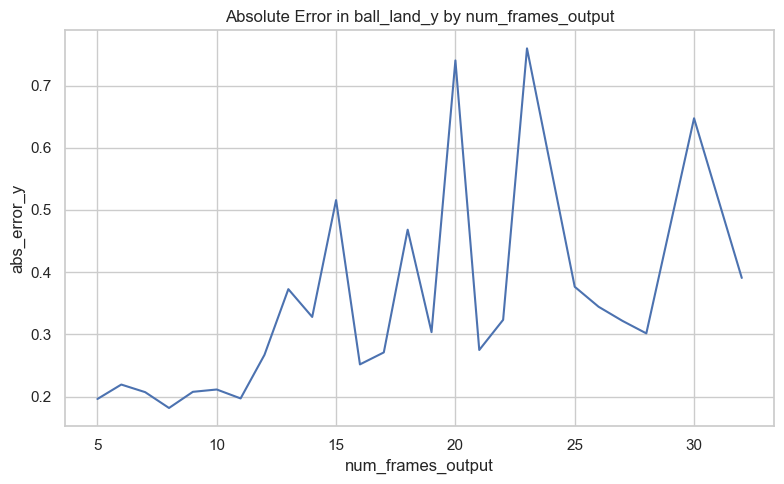

In [27]:
plt.figure(figsize=(8,5))
sns.lineplot(data=horizon_eval, x="num_frames_output", y="abs_error_y")
plt.title("Absolute Error in ball_land_y by num_frames_output")
plt.tight_layout()
plt.show()

## Hard Examples 

We inspect the largest prediction errors to identify failure cases and guide future feature engineering.

In [28]:
print(eval_df.columns.tolist())

['game_id', 'play_id', 'nfl_id', 'player_name', 'frame_id', 'x', 'y', 's', 'a', 'dir', 'o', 'absolute_yardline_number', 'player_weight', 'player_height_inches', 'player_age', 'is_moving_right', 'player_position', 'player_side', 'player_role', 'ball_land_x', 'ball_land_y', 'num_frames_output', 'dist_to_ball', 'speed_x', 'speed_y', 'acc_vector', 'x_centered', 'y_centered', 'momentum', 'speed_times_dir', 'x_times_speed', 'speed_bin_code', 'dx_to_ball', 'dy_to_ball', 'acc_x', 'acc_y', 'dir_minus_o', 'momentum_x', 'momentum_y', 'dist_from_field_center', 'x_prev', 'y_prev', 's_prev', 'a_prev', 'delta_x', 'delta_y', 'delta_s', 'delta_a', 'ball_land_x_pred', 'ball_land_y_pred', 'error_x', 'error_y', 'abs_error_x', 'abs_error_y']


In [29]:
hard_examples_x=eval_df.sort_values("abs_error_x", ascending=False).head(10)
display(hard_examples_x[
    [
    "game_id","play_id","nfl_id","player_name",
    "player_position","player_role",
    "ball_land_x","ball_land_y_pred","abs_error_x"
    ]
])

,game_id,play_id,nfl_id,player_name,player_position,player_role,ball_land_x,ball_land_y_pred,abs_error_x
147743,2023091800,3852,55133,Rashid Shaheed,WR,Targeted Receiver,53.160000,49.471542,6.022652
147744,2023091800,3852,55133,Rashid Shaheed,WR,Targeted Receiver,53.160000,49.113628,5.842560
144914,2023091800,1340,52417,C.J. Henderson,CB,Defensive Coverage,112.559998,9.871555,5.278290
64057,2023091012,327,42412,Tyler Lockett,WR,Targeted Receiver,116.269997,50.498119,5.193535
147745,2023091800,3852,55133,Rashid Shaheed,WR,Targeted Receiver,53.160000,49.811718,5.191677
64056,2023091012,327,42412,Tyler Lockett,WR,Targeted Receiver,116.269997,50.612305,5.173912
64054,2023091012,327,42412,Tyler Lockett,WR,Targeted Receiver,116.269997,50.329105,5.067024
64055,2023091012,327,42412,Tyler Lockett,WR,Targeted Receiver,116.269997,50.413586,5.055145
64051,2023091012,327,42412,Tyler Lockett,WR,Targeted Receiver,116.269997,50.427204,4.973991
64050,2023091012,327,42412,Tyler Lockett,WR,Targeted Receiver,116.269997,50.373653,4.972595


In [30]:
hard_examples_y=eval_df.sort_values("abs_error_y", ascending=False).head(10)
display(hard_examples_y[
    [
    "game_id","play_id","nfl_id","player_name",
    "player_position","player_role",
    "ball_land_y","ball_land_y_pred","abs_error_y"
    ]
])

,game_id,play_id,nfl_id,player_name,player_position,player_role,ball_land_y,ball_land_y_pred,abs_error_y
144916,2023091800,1340,52417,C.J. Henderson,CB,Defensive Coverage,4.24,10.467235,6.227235
144924,2023091800,1340,52417,C.J. Henderson,CB,Defensive Coverage,4.24,10.434011,6.194011
144923,2023091800,1340,52417,C.J. Henderson,CB,Defensive Coverage,4.24,10.400099,6.160099
144919,2023091800,1340,52417,C.J. Henderson,CB,Defensive Coverage,4.24,10.389136,6.149137
144915,2023091800,1340,52417,C.J. Henderson,CB,Defensive Coverage,4.24,10.383604,6.143604
144918,2023091800,1340,52417,C.J. Henderson,CB,Defensive Coverage,4.24,10.381084,6.141085
144917,2023091800,1340,52417,C.J. Henderson,CB,Defensive Coverage,4.24,10.381084,6.141085
144943,2023091800,1340,52417,C.J. Henderson,CB,Defensive Coverage,4.24,10.336650,6.096650
144920,2023091800,1340,52417,C.J. Henderson,CB,Defensive Coverage,4.24,10.269088,6.029088
144922,2023091800,1340,52417,C.J. Henderson,CB,Defensive Coverage,4.24,10.118260,5.878261


## Final Summary and Key Insights 

### Overall Performance Improvement

The v3 XGBoost models demostrate clear improvements over earlier iterations, confirmng the value of the richer spatial, directional, interaction-based, and temporal features.

    -Both 'ball_land_x' and 'ball_land_y' show improved predictive performance.
    -Error distribution are tighter and more stable than in earlier versions.
    -The v3 pipeline reduces extreme prediction failures and improves robustness across player groups.


### What Improved

The strongest gains appear to come form :

    -target-relative spatial features.
    -directional speed and acceleration decomposition.
    -momentum-style interaction features.
    -simple temporal lag/delta signals.
    
Together, these features provide the model with a much richer representation of player movement.


### Remaining Limitations

Despite these improvements, some challenges remain:

    -the model still operates on frame-level rows rather than full trajectories.
    -multi-player interactions are still only partially captured.
    -some difficult edge cases remain in the highest-error examples.

### Next Steps

Potential next improvements include:

1. Richer player-to-player interaction features
2. local spatial density features.
3. trajectory-based or sequence-based models.
4. Deployment of the current best model in a user friendly application.

---

### Conclusion

The v3 pipeline establishes the strongest modeling iteration so far and provides a strong foundation for final deployment and user-facing interaction.